In [2]:
include("parisiSolvers.jl")
using Plots
using Optim
using ADTypes: AutoForwardDiff
import ForwardDiff

In [3]:
K = 50
tgrid = collect(range(0.0, 1.0, length=K+1));

theta0 = log.(fill(0.05, K))  
g0 = theta_to_g(theta0);

### Pure spin, $p=3$

In [4]:
objective_p3 = make_objective(tgrid; p=3, L=8.0, Nx=1001, Q=40)
@time res_p3 = optimize(objective_p3, theta0, LBFGS(); autodiff=AutoForwardDiff()) 


293.703021 seconds (39.47 M allocations: 870.967 GiB, 43.57% gc time, 1.87% compilation time: <1% of which was recompilation)


 * Status: success

 * Candidate solution
    Final objective value:     1.150621e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 1.10e+01 ≰ 0.0e+00
    |x - x'|/|x'|          = 1.70e-02 ≰ 0.0e+00
    |f(x) - f(x')|         = 2.05e-12 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 1.78e-12 ≰ 0.0e+00
    |g(x)|                 = 7.76e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   287  (vs limit Inf)
    Iterations:    258
    f(x) calls:    341
    ∇f(x) calls:   341
    ∇f(x)ᵀv calls: 0


In [5]:
theta_star_p3 = Optim.minimizer(res_p3)
g_star_p3 = theta_to_g(theta_star_p3)

println("Optimized P(gamma) (p=3) = ", objective_p3(theta_star_p3))

Optimized P(gamma) (p=3) = 1.1506213530926495


### Pure spin, $p=2$

In [6]:
objective_p2 = make_objective(tgrid; p=2, L=8.0, Nx=1001, Q=40)
@time res_p2 = optimize(objective_p2, theta0, LBFGS(); autodiff=AutoForwardDiff()) 

 75.063934 seconds (1.71 M allocations: 229.457 GiB, 44.57% gc time, 0.01% compilation time)


 * Status: success

 * Candidate solution
    Final objective value:     3.104886e-01

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 0.00e+00 ≤ 0.0e+00
    |x - x'|/|x'|          = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 0.0e+00
    |g(x)|                 = 1.69e-02 ≰ 1.0e-08

 * Work counters
    Seconds run:   74  (vs limit Inf)
    Iterations:    1
    f(x) calls:    90
    ∇f(x) calls:   90
    ∇f(x)ᵀv calls: 0


In [7]:
theta_star_p2 = Optim.minimizer(res_p2)
g_star_p2 = theta_to_g(theta_star_p2)

println("Optimized P(gamma) (p=2) = ", objective_p2(theta_star_p2))

Optimized P(gamma) (p=2) = 0.3104886315465063


### Pure spin, $p=4$

In [8]:
objective_p4 = make_objective(tgrid; p=4, L=8.0, Nx=1001, Q=40)
@time res_p4 = optimize(objective_p4, theta0, LBFGS(); autodiff=AutoForwardDiff()) 

1116.079172 seconds (25.06 M allocations: 3.306 TiB, 44.28% gc time)


 * Status: success

 * Candidate solution
    Final objective value:     1.538164e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 1.10e+05 ≰ 0.0e+00
    |x - x'|/|x'|          = 3.79e-02 ≰ 0.0e+00
    |f(x) - f(x')|         = 1.33e-14 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 8.66e-15 ≰ 0.0e+00
    |g(x)|                 = 5.93e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   1115  (vs limit Inf)
    Iterations:    831
    f(x) calls:    1328
    ∇f(x) calls:   1328
    ∇f(x)ᵀv calls: 0


In [9]:
theta_star_p4 = Optim.minimizer(res_p4)
g_star_p4 = theta_to_g(theta_star_p4)

println("Optimized P(gamma) (p=4) = ", objective_p4(theta_star_p4))

Optimized P(gamma) (p=4) = 1.5381637117350264


### Plots

A priori we expect $p=3$ to have  $p=2$ to not be flat. For $p=3$ we don't really know, but expect flatness. For $p=4$ we expect flatness. 

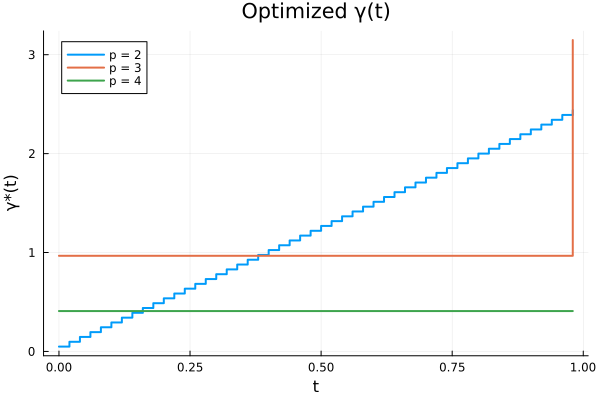

In [10]:
plot(
    tgrid[1:end-1],
    g_star_p2,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 2",
    title = "Optimized γ(t)",
)

plot!(
    tgrid[1:end-1],
    g_star_p3,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 3"
)


plot!(
    tgrid[1:end-1],
    g_star_p4,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 4"
)